# Mini-Project 3: Predictive Modeling and Optimization for Real Estate Investment

**Question:** How can a real estate company use house features to predict property value and make better investment decisions under a limited renovation budget?

This notebook combines a **neural network** for price prediction with a **linear program** for budget-constrained property selection on the Ames Housing dataset.

## Setup & Data Loading

Imports and a quick look at the raw dataset (2,930 rows, 82 columns).

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.show_dimensions", False)
os.makedirs("assets", exist_ok=True)

def save_fig(name):
    plt.savefig(f"assets/{name}.png", dpi=120, bbox_inches="tight")

In [2]:
df = pd.read_csv("data/ames_housing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.shape

(2930, 82)

---

## Part 1: Feature Selection and Problem Framing

**Target:** `SalePrice`, a dollar amount. This is a **regression** problem (we want a price, not a category).

**Selected features (8):**

| Feature | Why |
|---|---|
| `Overall Qual` | Top-correlated feature in Ames (overall material and finish quality) |
| `Gr Liv Area` | Above-grade living area, the main size driver |
| `Total Bsmt SF` | Basement size, extra usable space |
| `Garage Cars` | Garage capacity, a strong amenity signal |
| `Year Built` | Newer houses usually sell for more |
| `Year Remod/Add` | When the house was last renovated, directly relevant to Part 4 |
| `Neighborhood` | Location, location, location |
| `Full Bath` | Bathroom count |

> *Note: we initially picked `Lot Area` but swapped it for `Year Remod/Add`. `Lot Area` is heavily right-skewed (skew 12.82) and only weakly correlated with price (0.27). `Year Remod/Add` is much better behaved (skew -0.45) and ties cleanly into Part 4. Val and test scores were within noise either way.*

Quick sanity check on dtypes, ranges, and missing values:

In [4]:
features = [
    "Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Garage Cars",
    "Year Built", "Year Remod/Add", "Neighborhood", "Full Bath",
]
target = "SalePrice"

summary = df[features + [target]].describe(include="all").T
summary["missing"] = df[features + [target]].isna().sum()
summary["dtype"] = df[features + [target]].dtypes.astype(str)
summary[["dtype", "missing", "mean", "std", "min", "max"]]

,dtype,missing,mean,std,min,max
Overall Qual,int64,0,6.094881,1.411026,1.0,10.0
Gr Liv Area,int64,0,1499.690444,505.508887,334.0,5642.0
Total Bsmt SF,float64,1,1051.614544,440.615067,0.0,6110.0
Garage Cars,float64,1,1.766815,0.760566,0.0,5.0
Year Built,int64,0,1971.356314,30.245361,1872.0,2010.0
Year Remod/Add,int64,0,1984.266553,20.860286,1950.0,2010.0
Neighborhood,str,0,NaN,NaN,NaN,NaN
Full Bath,int64,0,1.566553,0.552941,0.0,4.0
SalePrice,int64,0,180796.060068,79886.692357,12789.0,755000.0


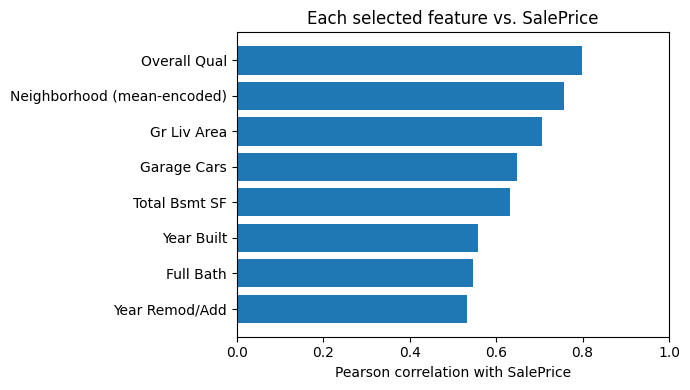

In [5]:
numeric_feats = [f for f in features if pd.api.types.is_numeric_dtype(df[f])]
numeric_corrs = df[numeric_feats + [target]].corr()[target].drop(target)
neigh_target_mean = df.groupby("Neighborhood")[target].transform("mean")
all_corrs = numeric_corrs.copy()
all_corrs["Neighborhood (mean-encoded)"] = neigh_target_mean.corr(df[target])
all_corrs = all_corrs.sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["tab:gray" if abs(v) < 0.3 else "tab:blue" for v in all_corrs]
ax.barh(all_corrs.index, all_corrs.values, color=colors)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel(f"Pearson correlation with {target}")
ax.set_title("Each selected feature vs. SalePrice")
ax.set_xlim(0, 1)
plt.tight_layout()
save_fig("feature_correlations")
plt.show()

---

## Part 2: Data Preparation and Baseline

**Preprocessing:** drop the 2 rows with missing values (negligible loss out of 2,930), one-hot encode `Neighborhood`, standard-scale numerics. The target is also standard-scaled internally so the NN trains on a well-behaved range.

**Splits:** 64% train, 16% val, 20% test (two nested 80/20 splits, fixed seed). The val set is for comparing architectures and tuning hyperparameters, so we don't peek at test during model selection. Test is kept for the final report.

**Metric:** RMSE in dollars (same units as `SalePrice`, and it penalizes big misses, which matter for investment decisions). Also report MAE and R^2.

**Baseline:** predict the training mean for every row. Any real model has to beat this.

In [6]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF",
                    "Garage Cars", "Year Built", "Year Remod/Add", "Full Bath"]
categorical_features = ["Neighborhood"]

df_clean = df.dropna(subset=features).reset_index(drop=True)
print(f"Dropped {len(df) - len(df_clean)} rows with missing values; {len(df_clean)} remain.")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

X = df_clean[features]
y = df_clean[target].astype(float).values

X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval_raw, y_trainval, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Dropped 2 rows with missing values; 2928 remain.
Train: (1873, 35), Val: (469, 35), Test: (586, 35)


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score(name, split, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:>14} [{split}] | RMSE ${rmse:>9,.0f} | MAE ${mae:>9,.0f} | R^2 {r2:.3f}")
    return {"model": name, "split": split, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []
mean_pred = y_train.mean()
results.append(score("Baseline", "val",  y_val,  np.full_like(y_val,  mean_pred)))
results.append(score("Baseline", "test", y_test, np.full_like(y_test, mean_pred)))

      Baseline [val] | RMSE $   82,349 | MAE $   58,043 | R^2 -0.001
      Baseline [test] | RMSE $   90,756 | MAE $   62,593 | R^2 -0.002


---

## Part 3: Neural Network Modeling

Train **four architectures** to probe the depth-vs-width trade-off, compare on the **val set**, then report the winner's score on test.

| Model | Architecture | Probes |
|---|---|---|
| NN-A | (32,) | low-capacity baseline |
| NN-B | (64, 32) | moderate depth |
| NN-C | (128,) | width without depth |
| NN-D | (64, 32, 16) | extra depth |

All trained with MSE loss / Adam / ReLU, early stopping on a 10% internal validation split.

In [8]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor

def make_nn(hidden_layer_sizes, **kwargs):
    base = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        **kwargs,
    )
    return TransformedTargetRegressor(regressor=base, transformer=StandardScaler())

architectures = {
    "NN-A (32)":       {"hidden_layer_sizes": (32,)},
    "NN-B (64,32)":    {"hidden_layer_sizes": (64, 32), "alpha": 1e-3},
    "NN-C (128)":      {"hidden_layer_sizes": (128,)},
    "NN-D (64,32,16)": {"hidden_layer_sizes": (64, 32, 16), "alpha": 1e-3},
}

models = {}
for name, kwargs in architectures.items():
    m = make_nn(**kwargs)
    m.fit(X_train, y_train)
    models[name] = m
    results.append(score(name, "val",  y_val,  m.predict(X_val)))
    results.append(score(name, "test", y_test, m.predict(X_test)))

     NN-A (32) [val] | RMSE $   29,313 | MAE $   18,427 | R^2 0.873
     NN-A (32) [test] | RMSE $   33,009 | MAE $   18,241 | R^2 0.867


  NN-B (64,32) [val] | RMSE $   28,995 | MAE $   17,967 | R^2 0.876
  NN-B (64,32) [test] | RMSE $   30,474 | MAE $   17,752 | R^2 0.887


    NN-C (128) [val] | RMSE $   30,428 | MAE $   18,518 | R^2 0.863
    NN-C (128) [test] | RMSE $   30,107 | MAE $   17,717 | R^2 0.890
NN-D (64,32,16) [val] | RMSE $   29,797 | MAE $   18,252 | R^2 0.869
NN-D (64,32,16) [test] | RMSE $   32,101 | MAE $   18,308 | R^2 0.875


                      RMSE                   MAE                R2       
split                 test        val       test        val   test    val
model                                                                    
Baseline        90,756.373 82,349.311 62,592.527 58,042.939 -0.002 -0.001
NN-A (32)       33,009.145 29,312.576 18,241.183 18,427.473  0.867  0.873
NN-B (64,32)    30,473.951 28,995.074 17,752.484 17,966.804  0.887  0.876
NN-C (128)      30,107.069 30,428.345 17,716.641 18,517.601  0.890  0.863
NN-D (64,32,16) 32,100.551 29,797.180 18,308.289 18,252.231  0.875  0.869

Val winner (architecture-only): NN-B (64,32) (val R^2 0.876)


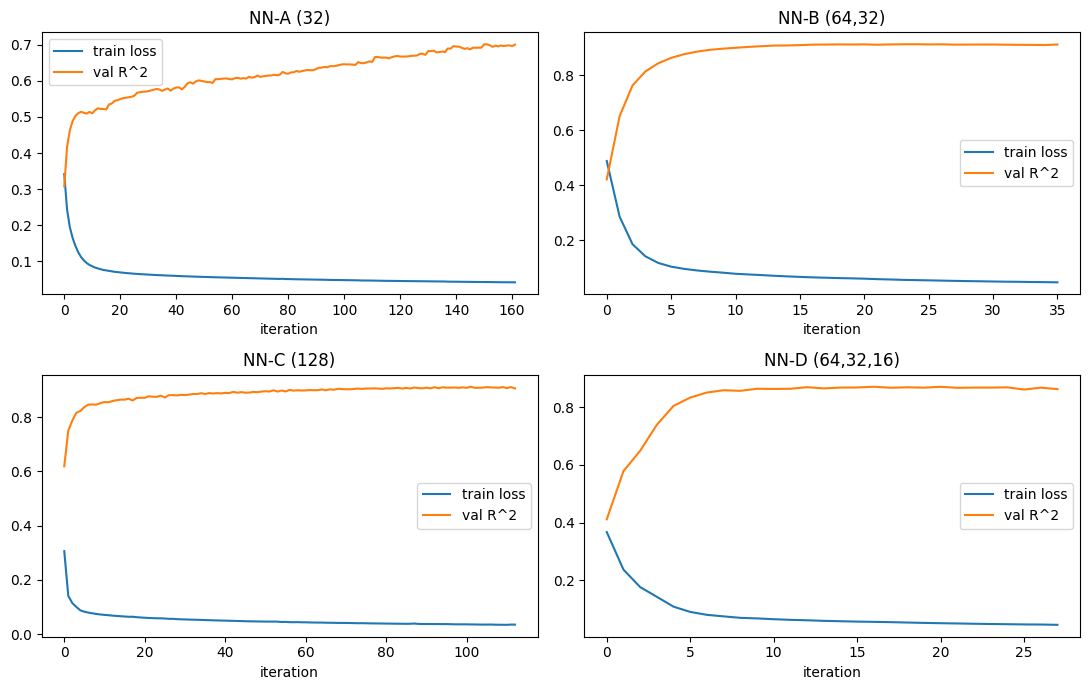

In [9]:
results_df = pd.DataFrame(results).pivot(index="model", columns="split", values=["RMSE", "MAE", "R2"])
print(results_df.to_string(float_format=lambda x: f"{x:,.3f}"))

val_scores = {r["model"]: r["R2"] for r in results if r["split"] == "val" and r["model"] != "Baseline"}
arch_winner_name = max(val_scores, key=val_scores.get)
print(f"\nVal winner (architecture-only): {arch_winner_name} (val R^2 {val_scores[arch_winner_name]:.3f})")

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, model) in zip(axes.ravel(), models.items()):
    inner = model.regressor_
    ax.plot(inner.loss_curve_, label="train loss")
    if hasattr(inner, "validation_scores_"):
        ax.plot(inner.validation_scores_, label="val R^2", color="tab:orange")
    ax.set_title(name)
    ax.set_xlabel("iteration")
    ax.legend()
plt.tight_layout()
save_fig("loss_curves")
plt.show()

### 3.1 Comparison and discussion

| Model | Val R^2 | Test R^2 |
|---|---|---|
| Baseline | -0.00 | -0.00 |
| NN-A (32) | 0.873 | 0.867 |
| **NN-B (64,32)** | **0.876** | **0.887** |
| NN-C (128) | 0.863 | 0.890 |
| NN-D (64,32,16) | 0.869 | 0.875 |

All four networks beat the baseline by a wide margin and cluster between 0.86 and 0.89. Diminishing returns kick in fast at this dataset size.

**Takeaways:**
- Depth slightly beats width: the wide single-layer net (NN-C) was worst on val.
- Going past 2 layers didn't help: NN-D's third layer added complexity for no gain.
- Val and test scores match closely for every model, so no overfitting to either split.
- Gaps between top models are under 0.01 R^2, basically noise. Multiple random seeds would firm this up.

**Winner (chosen on val):** NN-B. Test R^2 0.887, RMSE about $30K.

### 3.2 Hyperparameter tuning of NN-B

Architecture is locked in. Now tune two knobs that control how the network learns:

- **`alpha`**: L2 weight decay. Bigger means more regularization (less overfitting, but risks underfitting).
- **`learning_rate_init`**: Adam's starting step size. Too small slows training; too big makes it unstable.

Grid: 4 by 3 = 12 combos. Pick the winner on val and report test for the winner.

Best combo: alpha=0.1, lr=0.01, val R^2 0.883
Tuned NN-B test:    RMSE $30,899, R^2 0.884
Original NN-B test: RMSE $30,474, R^2 0.887


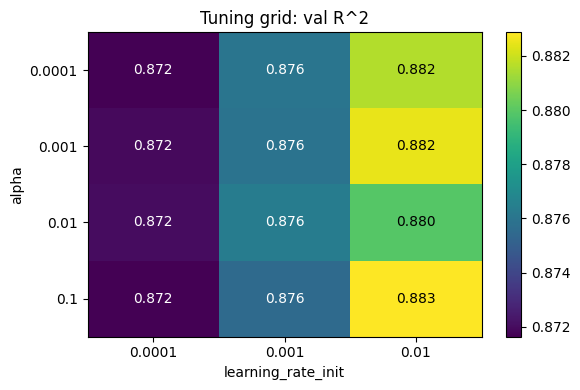

In [10]:
import itertools

alpha_grid = [1e-4, 1e-3, 1e-2, 1e-1]
lr_grid = [1e-4, 1e-3, 1e-2]

tuning_results = []
best_val_r2 = -np.inf
best_params = None
best_model = None

for alpha, lr in itertools.product(alpha_grid, lr_grid):
    m = make_nn(hidden_layer_sizes=(64, 32), alpha=alpha, learning_rate_init=lr)
    m.fit(X_train, y_train)
    val_r2 = r2_score(y_val, m.predict(X_val))
    tuning_results.append({"alpha": alpha, "lr": lr, "val_R2": val_r2})
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_params = {"alpha": alpha, "lr": lr}
        best_model = m

tune_df = pd.DataFrame(tuning_results).pivot(index="alpha", columns="lr", values="val_R2")
print(f"Best combo: alpha={best_params['alpha']}, lr={best_params['lr']}, val R^2 {best_val_r2:.3f}")

orig_b = next(r for r in results if r["model"] == "NN-B (64,32)" and r["split"] == "test")
tuned_test_pred = best_model.predict(X_test)
tuned_test_rmse = np.sqrt(mean_squared_error(y_test, tuned_test_pred))
tuned_test_r2 = r2_score(y_test, tuned_test_pred)
print(f"Tuned NN-B test:    RMSE ${tuned_test_rmse:,.0f}, R^2 {tuned_test_r2:.3f}")
print(f"Original NN-B test: RMSE ${orig_b['RMSE']:,.0f}, R^2 {orig_b['R2']:.3f}")

winner = best_model

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(tune_df.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(tune_df.columns))); ax.set_xticklabels([f"{c:g}" for c in tune_df.columns])
ax.set_yticks(range(len(tune_df.index))); ax.set_yticklabels([f"{r:g}" for r in tune_df.index])
ax.set_xlabel("learning_rate_init"); ax.set_ylabel("alpha")
ax.set_title("Tuning grid: val R^2")
for i in range(len(tune_df.index)):
    for j in range(len(tune_df.columns)):
        v = tune_df.values[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v < tune_df.values.mean() else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
save_fig("tuning_heatmap")
plt.show()

**Tuning takeaway:** the best combo (`alpha=0.1, lr=0.01`) bumps val R^2 from 0.876 to 0.883, but test R^2 stays basically flat (0.887 to 0.884). The gain is in noise range. The heatmap is mostly flat too, so the model isn't very sensitive to these knobs. To push past R^2 0.89 we'd need more features or a different model class (e.g. gradient boosting), not finer hyperparameter sweeps.

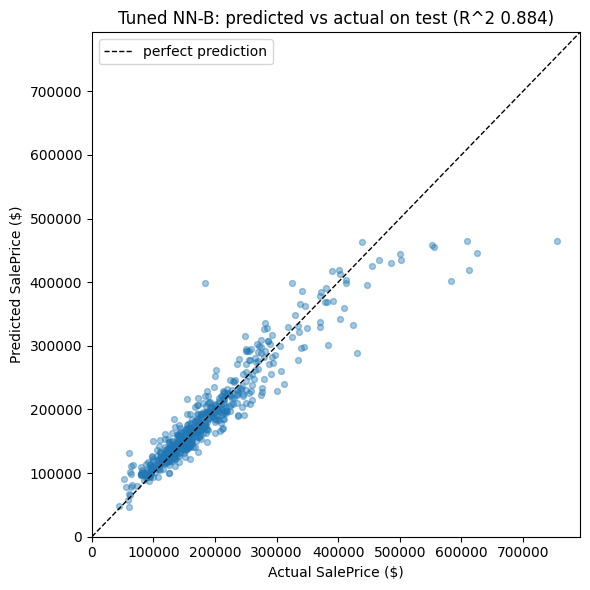

In [11]:
y_pred_test = winner.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, alpha=0.4, s=18)
lim = max(y_test.max(), y_pred_test.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1, label="perfect prediction")
ax.set_xlabel("Actual SalePrice ($)")
ax.set_ylabel("Predicted SalePrice ($)")
ax.set_title(f"Tuned NN-B: predicted vs actual on test (R^2 {tuned_test_r2:.3f})")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend()
plt.tight_layout()
save_fig("predicted_vs_actual")
plt.show()

---

## Part 4: Linear Programming Optimization for Housing Investment Selection

**Objective:** use linear programming to select a portfolio of houses that maximizes expected investment gain while staying under a renovation burden constraint.

This section connects the neural network from Part 3 to a portfolio decision: given a fixed renovation capacity, which subset of new candidate properties should the company pursue?

The LP runs only on the **586-house test set**, the houses the NN never saw during training. Using train or val rows would be circular: the NN was optimized to fit those, so PredictedPrice minus SalePrice on training data is mostly fit error rather than out-of-sample signal.

## Section 1: Build the Test-Set Candidate Pool

We pull the 586 test-set rows out of `df_clean`, attach the NN's predictions for those rows, and rename a few columns to camelCase for use in Part 4.

Required columns going forward: `SalePrice`, `PredictedPrice`, `OverallCond`, `YearRemodAdd`, `GrLivArea`.

In [12]:
# Build Part 4 candidate pool from the test set only.
# Using train or val rows would be circular: the NN was trained to fit them,
# so its predictions on those rows are not out-of-sample.
import pulp
import warnings
warnings.filterwarnings("ignore")

# Test-set indices preserved through the train_test_split
test_idx = X_test_raw.index

df = df_clean.loc[test_idx, ["SalePrice", "Overall Cond", "Year Remod/Add", "Gr Liv Area"]].copy()
df = df.rename(columns={
    "Overall Cond":   "OverallCond",
    "Year Remod/Add": "YearRemodAdd",
    "Gr Liv Area":    "GrLivArea",
})
df["PredictedPrice"] = winner.predict(X_test)
df = df.reset_index(drop=True)

print(f"Candidate pool: {len(df)} test-set properties")
print(f"\nFirst few rows:")
print(df.head())

required = ["SalePrice", "PredictedPrice", "OverallCond", "YearRemodAdd", "GrLivArea"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"
print(f"\nAll required columns present.")

Candidate pool: 586 test-set properties

First few rows:
   SalePrice  OverallCond  YearRemodAdd  GrLivArea  PredictedPrice
0     344133            5          2006       2253   298156.758651
1     132000            6          1950       1453   134671.470611
2     192100            6          1969       1851   212230.631042
3     198444            5          2007       1746   194040.689465
4     250000            5          2000       2198   292439.829747

All required columns present.


## Section 2: Construct the Expected Gain Variable

We define each property's **Expected Gain** as the NN residual: predicted price minus actual sale price.

### Definition:
$$\text{ExpectedGain}_i = \text{PredictedPrice}_i - \text{SalePrice}_i$$

### Interpretation:

- **Positive values:** the NN flags this property as priced lower than its features suggest. We treat these as candidates for closer inspection.
- **Negative values:** the NN thinks the property sold for more than its features support.

This is a heuristic, not a guaranteed signal. The NN sees the same features the market sees, so on test data the residual reflects either genuine market noise the model didn't capture or model error. We use it as a ranking tool, not a certified market-mispricing detector.

In [13]:
# Expected Gain = NN residual on the test set
df["ExpectedGain"] = df["PredictedPrice"] - df["SalePrice"]

print("Expected Gain summary:")
print(f"  Mean:    ${df['ExpectedGain'].mean():>12,.0f}")
print(f"  Median:  ${df['ExpectedGain'].median():>12,.0f}")
print(f"  Std:     ${df['ExpectedGain'].std():>12,.0f}")
print(f"  Min:     ${df['ExpectedGain'].min():>12,.0f}")
print(f"  Max:     ${df['ExpectedGain'].max():>12,.0f}")

undervalued = (df["ExpectedGain"] > 0).sum()
overvalued = (df["ExpectedGain"] < 0).sum()
print(f"\nNN-flagged candidates (ExpectedGain > 0): {undervalued} of {len(df)} ({100*undervalued/len(df):.1f}%)")
print(f"NN says priced too high   (ExpectedGain < 0): {overvalued} of {len(df)} ({100*overvalued/len(df):.1f}%)")

print("\nTop 10 by Expected Gain:")
top = df.nlargest(10, "ExpectedGain")[["SalePrice", "PredictedPrice", "ExpectedGain"]]
for i, (_, row) in enumerate(top.iterrows(), 1):
    print(f"  {i:>2}. ExpectedGain ${row['ExpectedGain']:>10,.0f}  "
          f"(Sale ${row['SalePrice']:>9,.0f}, Pred ${row['PredictedPrice']:>9,.0f})")

Expected Gain summary:
  Mean:    $         -82
  Median:  $       3,115
  Std:     $      30,926
  Min:     $    -290,920
  Max:     $     215,182

NN-flagged candidates (ExpectedGain > 0): 327 of 586 (55.8%)
NN says priced too high   (ExpectedGain < 0): 259 of 586 (44.2%)

Top 10 by Expected Gain:
   1. ExpectedGain $   215,182  (Sale $  183,850, Pred $  399,032)
   2. ExpectedGain $    74,508  (Sale $  325,000, Pred $  399,508)
   3. ExpectedGain $    71,831  (Sale $   60,000, Pred $  131,831)
   4. ExpectedGain $    67,540  (Sale $  247,900, Pred $  315,440)
   5. ExpectedGain $    61,817  (Sale $  201,000, Pred $  262,817)
   6. ExpectedGain $    61,181  (Sale $  155,000, Pred $  216,181)
   7. ExpectedGain $    55,581  (Sale $  280,750, Pred $  336,331)
   8. ExpectedGain $    52,681  (Sale $  200,000, Pred $  252,681)
   9. ExpectedGain $    50,682  (Sale $  134,000, Pred $  184,682)
  10. ExpectedGain $    50,269  (Sale $  100,000, Pred $  150,269)


## Section 3: Calculate the Renovation Burden Proxy

The Ames dataset has no explicit renovation cost column, so we build a **Renovation Burden** proxy from three real Ames features. Each component captures a different cost driver, and we standardize each one (z-score) before summing so they contribute on equal footing rather than letting raw scale dominate.

### Definition:
$$\text{RenovationBurden}_i = z\big(10 - \text{OverallCond}_i\big) + z\big(2026 - \text{YearRemodAdd}_i\big) + z\big(\text{GrLivArea}_i\big)$$

where $z(\cdot)$ z-scores the column, and a final shift puts the minimum at 0 so all values are non-negative.

### Component interpretation:

1. **Condition term:** higher burden for worse condition (`OverallCond` 1 to 10).
2. **Age term:** higher burden for properties remodeled longer ago.
3. **Size term:** higher burden for larger properties (more labor).

All three components come from real Ames features. Z-scoring removes the arbitrary unit mismatch between condition (1-10), years (decades), and area (thousands of sqft).

In [14]:
# Renovation Burden: z-score each component so units are comparable, then sum.
# Final shift makes the minimum 0 so the burden is non-negative for the budget framing.
def z(s):
    return (s - s.mean()) / s.std()

condition_z = z(10 - df["OverallCond"])
age_z       = z(2026 - df["YearRemodAdd"])
size_z      = z(df["GrLivArea"])

df["RenovationBurden"] = condition_z + age_z + size_z
df["RenovationBurden"] = df["RenovationBurden"] - df["RenovationBurden"].min()

print("Renovation Burden summary (standardized):")
print(f"  Mean:    {df['RenovationBurden'].mean():.2f}")
print(f"  Median:  {df['RenovationBurden'].median():.2f}")
print(f"  Std:     {df['RenovationBurden'].std():.2f}")
print(f"  Min:     {df['RenovationBurden'].min():.2f}")
print(f"  Max:     {df['RenovationBurden'].max():.2f}")

print("\nTop 10 by burden:")
top = df.nlargest(10, "RenovationBurden")[["OverallCond", "YearRemodAdd", "GrLivArea", "RenovationBurden"]]
for i, (_, row) in enumerate(top.iterrows(), 1):
    print(f"  {i:>2}. burden {row['RenovationBurden']:5.2f}  "
          f"(cond {row['OverallCond']:.0f}, year {row['YearRemodAdd']:.0f}, area {row['GrLivArea']:,.0f} sqft)")

Renovation Burden summary (standardized):
  Mean:    5.25
  Median:  5.14
  Std:     1.59
  Min:     0.00
  Max:     11.34

Top 10 by burden:
   1. burden 11.34  (cond 5, year 2009, area 5,095 sqft)
   2. burden 10.27  (cond 2, year 1950, area 1,666 sqft)
   3. burden 10.06  (cond 1, year 1950, area 1,086 sqft)
   4. burden  9.98  (cond 3, year 1950, area 1,981 sqft)
   5. burden  9.71  (cond 1, year 1950, area 904 sqft)
   6. burden  9.63  (cond 6, year 1995, area 4,316 sqft)
   7. burden  9.22  (cond 4, year 1974, area 2,646 sqft)
   8. burden  9.16  (cond 5, year 1996, area 3,627 sqft)
   9. burden  8.97  (cond 4, year 1970, area 2,414 sqft)
  10. burden  8.91  (cond 4, year 1950, area 1,889 sqft)


## Section 4: Derive the Budget from the Dataset

The Ames dataset has no explicit budget. We derive one from the data itself: the company can handle 10% of the total renovation workload across the 586 candidate properties.

### Definition:
$$\text{BUDGET} = 0.10 \times \sum_{i=1}^{n} \text{RenovationBurden}_i$$

This is a capacity constraint, not a dollar budget. It scales naturally with the size and composition of the candidate pool: a pool of older, larger, worse-condition homes produces a tighter effective budget than a pool of newer, smaller, well-maintained ones.

In [15]:
total_burden = df["RenovationBurden"].sum()
BUDGET_FRACTION = 0.10
BUDGET = BUDGET_FRACTION * total_burden

print(f"Total candidate-pool burden:   {total_burden:.2f}")
print(f"Company capacity fraction:     {BUDGET_FRACTION:.0%}")
print(f"Derived renovation budget:     {BUDGET:.2f}")

avg_burden = df["RenovationBurden"].mean()
print(f"\nAverage burden per property:   {avg_burden:.2f}")
print(f"Budget equivalent to roughly:  {BUDGET / avg_burden:.0f} avg-burden properties")
print(f"\nLP constraint:")
print(f"  maximize total ExpectedGain")
print(f"  subject to total RenovationBurden <= {BUDGET:.2f}")

Total candidate-pool burden:   3073.93
Company capacity fraction:     10%
Derived renovation budget:     307.39

Average burden per property:   5.25
Budget equivalent to roughly:  59 avg-burden properties

LP constraint:
  maximize total ExpectedGain
  subject to total RenovationBurden <= 307.39


## Section 5: Formulate the Binary Integer Linear Program

We formulate the investment selection problem as a 0/1 knapsack using PuLP.

### Decision variables:
$$x_i \in \{0, 1\} \quad \text{for } i = 1, 2, \ldots, n$$

$x_i = 1$ means renovate property $i$, $x_i = 0$ means skip it.

### Objective:
$$\text{maximize} \quad \sum_{i=1}^{n} \text{ExpectedGain}_i \cdot x_i$$

Pick the portfolio that maximizes total expected gain.

### Constraint:
$$\sum_{i=1}^{n} \text{RenovationBurden}_i \cdot x_i \leq \text{BUDGET}$$

Total renovation work across selected properties must not exceed the company's capacity.

In [16]:
# Build the binary integer LP: maximize ExpectedGain subject to RenovationBurden <= BUDGET

investment_problem = pulp.LpProblem("Housing_Investment_Selection", pulp.LpMaximize)

# Binary decision variable per property
decision_variables = {idx: pulp.LpVariable(f"invest_{idx}", cat="Binary") for idx in df.index}

# Objective
investment_problem += pulp.lpSum(
    df.loc[idx, "ExpectedGain"] * decision_variables[idx] for idx in df.index
), "Total_Expected_Gain"

# Constraint
investment_problem += pulp.lpSum(
    df.loc[idx, "RenovationBurden"] * decision_variables[idx] for idx in df.index
) <= BUDGET, "Renovation_Burden_Constraint"

print(f"LP formulation built:")
print(f"  Objective:    maximize total ExpectedGain")
print(f"  Variables:    {len(decision_variables)} binary (one per property)")
print(f"  Constraints:  1 (renovation burden <= {BUDGET:.2f})")

LP formulation built:
  Objective:    maximize total ExpectedGain
  Variables:    586 binary (one per property)
  Constraints:  1 (renovation burden <= 307.39)


## Section 6: Solve the LP

Use PuLP's CBC (open-source MILP solver). The solver runs branch-and-bound to find the exact optimum across all $2^{586}$ possible binary assignments. We assert the solver returns "Optimal" status before trusting any results.

In [17]:
status = investment_problem.solve(pulp.PULP_CBC_CMD(msg=0))

status_names = {
    1: "OPTIMAL (solution found)",
    0: "NOT SOLVED",
    -1: "INFEASIBLE (no feasible solution)",
    -2: "UNBOUNDED",
    -3: "UNDEFINED",
}
status_description = status_names.get(status, f"UNKNOWN ({status})")
print(f"Solver status: {status_description}")

assert status == 1, f"LP did not solve to optimality: {status_description}"

optimal_gain = pulp.value(investment_problem.objective)
print(f"Optimal total Expected Gain: ${optimal_gain:,.0f}")

Solver status: OPTIMAL (solution found)
Optimal total Expected Gain: $2,384,682


## Section 7: Extract and Inspect the Selected Portfolio

Pull out the properties the optimizer selected (decision variable = 1) and summarize the portfolio.

In [18]:
selected_indices = [idx for idx, var in decision_variables.items() if var.varValue == 1]
selected_df = df.loc[selected_indices].sort_values("ExpectedGain", ascending=False)

num_selected = len(selected_indices)
total_gain = selected_df["ExpectedGain"].sum()
total_burden_used = selected_df["RenovationBurden"].sum()
remaining_capacity = BUDGET - total_burden_used

print(f"Selected: {num_selected} of {len(df)} properties ({100*num_selected/len(df):.1f}%)")
print(f"\nPortfolio metrics:")
print(f"  Total Expected Gain:  ${total_gain:>10,.0f}")
print(f"  Total burden used:    {total_burden_used:>10.2f}  (limit {BUDGET:.2f})")
print(f"  Remaining capacity:   {remaining_capacity:>10.2f}  ({100*remaining_capacity/BUDGET:.1f}% unused)")

print(f"\nSelected-property averages:")
print(f"  Sale price:        ${selected_df['SalePrice'].mean():>10,.0f}")
print(f"  Predicted price:   ${selected_df['PredictedPrice'].mean():>10,.0f}")
print(f"  Expected gain:     ${selected_df['ExpectedGain'].mean():>10,.0f}")
print(f"  Burden:            {selected_df['RenovationBurden'].mean():>10.2f}")
print(f"  Overall Cond:      {selected_df['OverallCond'].mean():.1f} / 10")
print(f"  Years since remod: {(2026 - selected_df['YearRemodAdd']).mean():.1f}")
print(f"  Living area:       {selected_df['GrLivArea'].mean():,.0f} sqft")

print("\nSelected portfolio (top 20 by ExpectedGain):")
display_cols = ["SalePrice", "PredictedPrice", "ExpectedGain", "RenovationBurden",
                "OverallCond", "YearRemodAdd", "GrLivArea"]
print(selected_df[display_cols].head(20).to_string(float_format=lambda x: f"{x:,.2f}"))

Selected: 60 of 586 properties (10.2%)

Portfolio metrics:
  Total Expected Gain:  $ 2,384,682
  Total burden used:        307.35  (limit 307.39)
  Remaining capacity:         0.04  (0.0% unused)

Selected-property averages:
  Sale price:        $   179,272
  Predicted price:   $   219,017
  Expected gain:     $    39,745
  Burden:                  5.12
  Overall Cond:      5.5 / 10
  Years since remod: 31.2
  Living area:       1,700 sqft

Selected portfolio (top 20 by ExpectedGain):
     SalePrice  PredictedPrice  ExpectedGain  RenovationBurden  OverallCond  YearRemodAdd  GrLivArea
552     183850      399,032.42    215,182.42             11.34            5          2009       5095
280     325000      399,507.80     74,507.80              6.51            5          2007       2504
438      60000      131,831.32     71,831.32              8.26            3          1958       1276
255     247900      315,440.03     67,540.03              5.42            5          1997       1682
336  

## Section 8: Visualize the Selection Decision

Scatter plot of every candidate property: x-axis is Renovation Burden, y-axis is Expected Gain. Selected properties (blue) versus skipped (red).

The picture makes the trade-off explicit: we want the upper-left corner (high gain, low burden), and the constraint forces us to pass on otherwise attractive properties when they sit too far right.

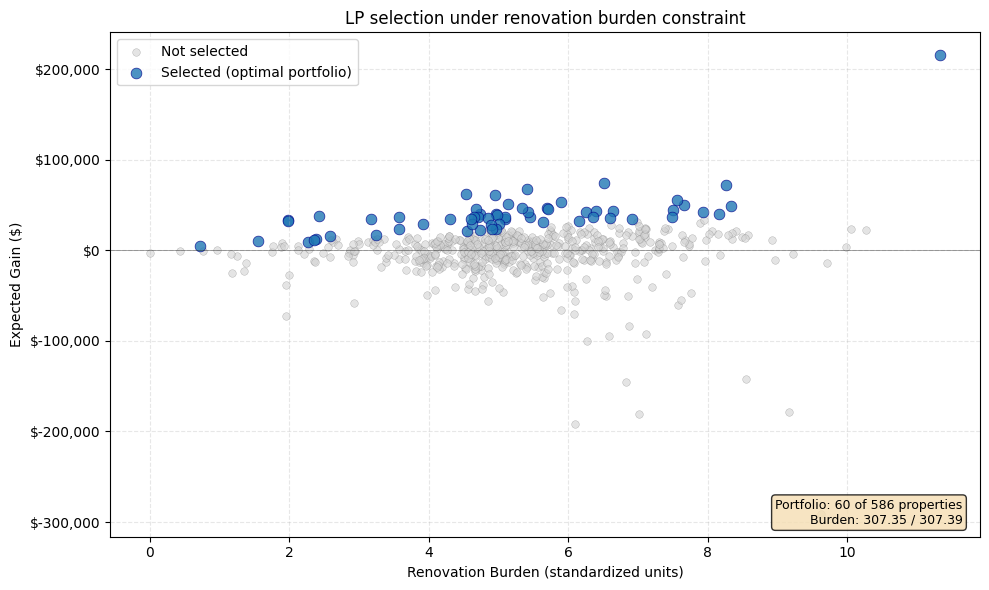

In [19]:
df["Selected"] = df.index.isin(selected_indices)

fig, ax = plt.subplots(figsize=(10, 6))

not_sel = df[~df["Selected"]]
sel = df[df["Selected"]]

ax.scatter(not_sel["RenovationBurden"], not_sel["ExpectedGain"],
           color="lightgray", alpha=0.6, s=30, label="Not selected", edgecolors="gray", linewidth=0.3)
ax.scatter(sel["RenovationBurden"], sel["ExpectedGain"],
           color="tab:blue", alpha=0.8, s=60, label="Selected (optimal portfolio)",
           edgecolors="darkblue", linewidth=0.5)

ax.axhline(0, color="black", lw=0.5, alpha=0.5)
ax.set_xlabel("Renovation Burden (standardized units)")
ax.set_ylabel("Expected Gain ($)")
ax.set_title("LP selection under renovation burden constraint")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="best")

ax.text(0.98, 0.02,
        f"Portfolio: {num_selected} of {len(df)} properties\n"
        f"Burden: {total_burden_used:.2f} / {BUDGET:.2f}",
        transform=ax.transAxes, fontsize=9,
        verticalalignment="bottom", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.tight_layout()
save_fig("lp_selection")
plt.show()

## Section 9: Interpretation of the Objective and Constraint

### A. Objective: maximize total Expected Gain

$$\text{maximize} \quad \sum_{i=1}^{n} \text{ExpectedGain}_i \cdot x_i$$

where $\text{ExpectedGain}_i = \text{PredictedPrice}_i - \text{SalePrice}_i$.

The LP picks a subset of properties to maximize the sum of NN residuals across selected properties. Properties where the NN's prediction is well above the sale price contribute the most. The model trained on Ames features predicts prices that reflect typical pricing for similar houses; properties with large positive residuals are flagged as candidates worth a closer look.

This is a heuristic, not a guarantee. Predictions on the test set are out-of-sample, so residuals carry real information, but they're still subject to the NN's own noise (about $30K test RMSE). Treat the LP output as a ranked candidate list, not a certified buy list.

### B. Constraint: renovation burden limit

$$\sum_{i=1}^{n} \text{RenovationBurden}_i \cdot x_i \leq \text{BUDGET}$$

The company has finite renovation capacity. Burden combines three real Ames features (condition, time since remodel, size), each z-scored so they contribute on equal footing. The budget is set at 10% of total candidate-pool burden, which scales with the actual mix of properties.

Without the constraint the optimizer would just pick everything with a positive Expected Gain. With it, the LP has to balance gain against burden, and high-burden outliers can crowd out several smaller, lower-burden picks.

### C. The trade-off

Many of the highest-residual properties also carry high burden (older, larger, poorer condition). The constraint makes the LP weigh gain-per-unit-burden rather than absolute gain, so the selected portfolio is not just the top N gainers.

## Section 10: Business Interpretation and Insights

### Summary of results

The LP selected **60 of the 586** test-set candidates for an optimal portfolio with **$2.38M total Expected Gain** (about $40K per pick on average). The capacity constraint binds at 100%: every available unit of renovation budget is used.

### Why these houses got selected

Looking at the actual portfolio, the picks are not the "well-maintained, recently remodeled, modest size" set you might expect from a renovation budget. They line up with where the NN's residuals are largest:

- **Slightly larger homes** (1,700 sqft avg vs 1,513 dataset-wide). The portfolio's size advantage is modest on average but the top picks include one outlier at 5,095 sqft (max burden 11.34, gain $215K). Larger homes carry larger absolute residuals.
- **Newer remodels** (31 years since remodel vs 42 dataset-wide). The age term in the burden formula penalizes older properties, so the LP is systematically pushed toward more-recently-modernized ones, even though the model itself never sees an "age" preference.
- **Mid-tier condition matches the dataset** (5.5/10 in both selected and all). Condition is not the differentiator here. The age and size terms in the burden formula do the filtering.

The top selected pick has the maximum burden in the entire dataset (11.34), but the LP took it anyway because the gain ($215K) is roughly 5x the next-best gain. High-burden outliers can win if their gain is large enough.

### What got excluded

- Properties with Expected Gain at or below 0 (the NN priced them at or above the sale price). No upside, no reason to include.
- High-burden, low-gain properties: a poor-condition, large, old home with only modest expected gain. Multiple lower-burden picks beat one of those.

### Honest caveat about Expected Gain

Expected Gain is the NN's residual on out-of-sample data, not a certified market-mispricing signal. The NN sees the same features the market sees (size, quality, neighborhood), so it can't reveal information the market doesn't already price in. What it can do is rank properties by how far they deviate from typical Ames pricing patterns, which is a useful first-pass screen even if it isn't a guaranteed signal. The NN's $30K test RMSE means individual residuals carry meaningful uncertainty.

### Strategic notes

1. **Treat the LP output as a candidate list, not a buy list.** The portfolio is a starting point for human review, not a final acquisition order.
2. **Burden weights are equal by design.** Z-scoring puts condition, age, and size on the same footing. If the company has stronger feelings about which factor matters most (e.g., labor for size dominates), the weights can be adjusted upstream.
3. **Capacity scales with pool composition.** If the company widens the candidate pool, the budget rescales automatically; no need to retune a hardcoded dollar amount.
4. **Refine over time.** As the company executes on selected picks, compare actual returns to Expected Gain to validate (or correct) the model's residual rankings.

In [20]:
# Customized portfolio summary keyed off actual results

avg_gain_per_property = total_gain / num_selected if num_selected > 0 else 0
capacity_utilization = (total_burden_used / BUDGET) * 100 if BUDGET > 0 else 0

print(f"Portfolio metrics:")
print(f"  Selected:                 {num_selected} of {len(df)} ({100*num_selected/len(df):.1f}%)")
print(f"  Total Expected Gain:      ${total_gain:,.0f}")
print(f"  Avg gain per property:    ${avg_gain_per_property:,.0f}")
print(f"  Capacity used:            {capacity_utilization:.1f}%")
print(f"  Remaining capacity:       {remaining_capacity:.2f}  ({100*remaining_capacity/BUDGET:.1f}%)")

if num_selected > 0:
    print(f"\nSelected vs. all candidates:")
    print(f"  Condition:        {selected_df['OverallCond'].mean():.1f}  vs  {df['OverallCond'].mean():.1f} (all)")
    print(f"  Living area:      {selected_df['GrLivArea'].mean():>6,.0f} vs  {df['GrLivArea'].mean():>6,.0f} sqft (all)")
    print(f"  Years since remod: {(2026 - selected_df['YearRemodAdd']).mean():>4.1f} vs  {(2026 - df['YearRemodAdd']).mean():>4.1f} (all)")
    print(f"  Expected gain:    ${selected_df['ExpectedGain'].mean():>10,.0f} vs  ${df['ExpectedGain'].mean():>9,.0f} (all)")

Portfolio metrics:
  Selected:                 60 of 586 (10.2%)
  Total Expected Gain:      $2,384,682
  Avg gain per property:    $39,745
  Capacity used:            100.0%
  Remaining capacity:       0.04  (0.0%)

Selected vs. all candidates:
  Condition:        5.5  vs  5.5 (all)
  Living area:       1,700 vs   1,513 sqft (all)
  Years since remod: 31.2 vs  41.8 (all)
  Expected gain:    $    39,745 vs  $      -82 (all)
